# Exploratory Data Analysis (EDA)


### Objective
Explore the cleaned dataset to understand feature distributions, relationships, and patterns that may influence machine diagnostics before feature engineering and model development.

In [3]:
## 1. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
## 2. Load the Cleaned Dataset
df = pd.read_csv("../data/processed/cleaned_data.csv",
                 parse_dates=["Date"])

In [9]:
# Display the first five rows
df.head()

,Date,System,Control,Type,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Diagnostic
0,2014-04-15 11:56:00,0,C,M,300.064358,310.033081,1541.242402,42.8,0.00000,No failure
1,2014-04-12 16:09:00,0,A,L,298.200000,308.700000,1408.000000,39.9,110.52424,No failure
2,2014-04-13 01:13:00,0,A,L,298.100000,308.500000,1498.000000,39.9,110.52424,No failure
3,2014-07-24 20:35:00,0,B,L,300.064358,310.033081,1433.000000,39.5,110.52424,No failure
4,2014-07-22 01:31:00,0,C,L,300.064358,310.033081,1541.242402,40.0,9.00000,No failure


In [10]:
# Check the dimensions of the dataset (rows and columns)
df.shape

(10000, 10)

In [11]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     10000 non-null  datetime64[us]
 1   System                   10000 non-null  int64         
 2   Control                  10000 non-null  str           
 3   Type                     10000 non-null  str           
 4   Air temperature (K)      10000 non-null  float64       
 5   Process temperature (K)  10000 non-null  float64       
 6   Rotational speed (rpm)   10000 non-null  float64       
 7   Torque (Nm)              10000 non-null  float64       
 8   Tool wear (min)          10000 non-null  float64       
 9   Diagnostic               10000 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(1), str(3)
memory usage: 781.4 KB


In [12]:
# Count the occurrences of each diagnostic class
df["Diagnostic"].value_counts()

Diagnostic
No failure                  9652
Heat Dissipation Failure     106
Overstrain Failure            98
Power Failure                 83
Tool Wear Failure             42
Random Failures               19
Name: count, dtype: int64

### Observation

- The dataset is highly imbalanced.
- "No failure" is the dominant class with 9,652 records (96.52%).
- All failure classes are relatively rare, with "Random Failures" being the least frequent (19 records).
- This imbalance suggests that accuracy alone may not be a reliable evaluation metric, and additional metrics such as Precision, Recall, and F1-score should be considered during model evaluation.

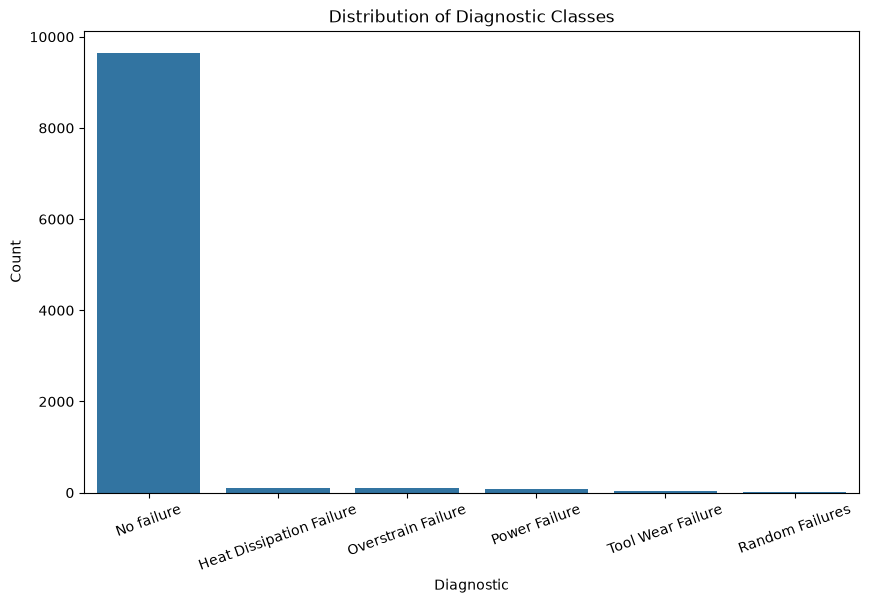

In [14]:
# Visualize the distribution of the target variable
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Diagnostic",order=df["Diagnostic"].value_counts().index)

plt.title("Distribution of Diagnostic Classes")
plt.xlabel("Diagnostic")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()


### Observation

- The "No failure" class is the dominant category in the dataset.
- Failure classes occur much less frequently, indicating a highly imbalanced dataset.
- Random Failures is the least frequent class.
- Class imbalance should be considered during model evaluation since accuracy alone may not reflect model performance.

In [15]:
# Calculate the percentage distribution of each diagnostic class
diagnostic_percentage = df["Diagnostic"].value_counts(normalize=True) * 100

diagnostic_percentage.round(2)

Diagnostic
No failure                  96.52
Heat Dissipation Failure     1.06
Overstrain Failure           0.98
Power Failure                0.83
Tool Wear Failure            0.42
Random Failures              0.19
Name: proportion, dtype: float64

### Observation

- The "No failure" class accounts for approximately 96.52% of the dataset.
- All failure classes together represent only about 3.48% of the observations.
- This confirms that the dataset is highly imbalanced.
- The imbalance should be considered during model training and evaluation.